# 04 — Case Study: Illegal Dumping

**Primary question:** *What does illegal dumping look like as an operational problem in Los Angeles?*

## Filtering decisions

Standard operational filter per [`analysis_standards.md`](../docs/analysis_standards.md) §1 (exclude intake artifacts, dead statuses, duplicate-coded closures), restricted to **January 1 – June 30, 2026** (six complete months). For duration metrics we additionally restrict to cases **created before June 1** so every case has had ≥30 days to close (censoring rule, standards §6.3), and we checked the category's time series for batch-import spikes (standards §8.9) — none found (max single hour: 204 cases, organic).

Assumptions in force: reports ≠ problems; one case ≠ one unique problem; closed ≠ fixed (we use outcome classes throughout).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

raw = pd.read_csv(Path("../data/raw/myla311_cases_2026.csv"), low_memory=False)

INTAKE_ARTIFACTS = {"Information-Only", "Feedback", "Program Research"}
DEAD_STATUSES = {"Cancelled", "Potential Duplicate", "Duplicate Confirm"}
DUP_CODES = ("DUP-", "B-Duplicated", "CDR-")

def standard_operational_filter(df):
    """Standard filter per docs/analysis_standards.md section 1."""
    out = df[~df["RequestType"].isin(INTAKE_ARTIFACTS)]
    out = out[~out["Status"].isin(DEAD_STATUSES)]
    out = out[~out["ResolutionCode"].fillna("").str.startswith(DUP_CODES)]
    return out

op = standard_operational_filter(raw).copy()
op["created"] = pd.to_datetime(op["CreatedDate"], format="mixed")
op = op[op["created"] < "2026-07-01"]

il = op[op["RequestType"] == "Illegal Dumping Item Pickup"].copy()
ip = op[op["RequestType"] == "Item Pickups"].copy()
print(f"operational cases Jan-Jun: {len(op):,}")
print(f"Illegal Dumping Item Pickup: {len(il):,}   Item Pickups: {len(ip):,}")

operational cases Jan-Jun: 803,955
Illegal Dumping Item Pickup: 231,547   Item Pickups: 234,015


## Context: Illegal Dumping vs. scheduled Item Pickups

Calibration only — the scheduled bulky-pickup program is context, not the object of study. An `Item Pickups` case is a resident scheduling collection of *their own* discarded items (a free LASAN service); an `Illegal Dumping Item Pickup` case is (nominally) a report about *someone else's* dumped material in the public right-of-way.

In [2]:
def outcome_class(code):
    """ResolutionCode -> outcome class, per analysis_standards.md section 5 (as amended)."""
    if pd.isna(code):
        return "none"
    c = code.strip()
    if c.startswith(("AR-", "RC-", "COM-", "WC-", "SARH", "SARC", "PFR-", "LR-", "TR-", "BR-",
                     "RSP-", "IWO-", "MNT-", "VM-", "VMRB", "OPUVM", "BF-", "R-Repaired",
                     "TSC-", "AD-Request")):
        return "work_performed"
    if c.startswith(("QC-", "NCPP", "ASG-", "UTM-", "NAT-", "VNL-", "NAR-", "BINS-", "ASAT-")):
        return "no_service_needed"
    if c.startswith(("C-Closed", "1004", "RF-", "GI-", "IP-", "AAA-", "IO-", "CL-")):
        return "administrative_close"
    if c.startswith("C-Report"):
        return "acknowledged"
    if c.startswith("1003"):
        return "referred"
    if c.startswith(("DUP-", "B-Duplicated", "CDR-")):
        return "duplicate"
    if c.startswith(("RCAN", "1005", "CANC", "CG-", "RBI-", "RWG-", "REW-", "CCAN")):
        return "cancelled"
    return "unclassified"

def profile(df_cat):
    closed = df_cat[(df_cat["Status"] == "Closed") & (df_cat["created"] < "2026-06-01")]
    days = (pd.to_datetime(closed["ClosedDate"], format="mixed") - closed["created"]).dt.total_seconds() / 86400
    oc = closed["ResolutionCode"].map(outcome_class).value_counts(normalize=True) * 100
    return {
        "cases (Jan-Jun)": f"{len(df_cat):,}",
        "% of operational demand": f"{len(df_cat)/len(op):.1%}",
        "owner: LASAN core": f"{df_cat['Owner'].isin(['LASAN','Sanitation']).mean():.0%}",
        "owner: LSD (encampment div.)": f"{df_cat['Owner'].isin(['LSD','LASAN - LSD']).mean():.0%}",
        "top AssignTo": ", ".join(df_cat["AssignTo"].value_counts().head(3).index),
        "outcome: work_performed": f"{oc.get('work_performed', 0):.0f}%",
        "outcome: no_service_needed": f"{oc.get('no_service_needed', 0):.0f}%",
        "median days to close": f"{days.median():.1f}",
        "p75 days to close": f"{days.quantile(0.75):.1f}",
        "source: phone": f"{(df_cat['RequestSource'] == 'Call').mean():.0%}",
        "source: self-service web": f"{(df_cat['RequestSource'] == 'Self Service').mean():.0%}",
        "reported anonymously": f"{df_cat['Anonymous'].mean():.0%}",
    }

pd.DataFrame({"Illegal Dumping": profile(il), "Item Pickups (context)": profile(ip)})

,Illegal Dumping,Item Pickups (context)
cases (Jan-Jun),"231,547","234,015"
% of operational demand,28.8%,29.1%
owner: LASAN core,82%,98%
owner: LSD (encampment div.),18%,1%
top AssignTo,"NC, SLA, EV","EV, WV, NC"
outcome: work_performed,70%,76%
outcome: no_service_needed,26%,22%
median days to close,2.1,2.1
p75 days to close,4.9,4.9
source: phone,31%,57%


In [3]:
# Geography: does dumping tilt somewhere pickups don't?
apc_il = il["APC"].value_counts(normalize=True) * 100
apc_ip = ip["APC"].value_counts(normalize=True) * 100
geo = pd.DataFrame({"Illegal Dumping %": apc_il, "Item Pickups %": apc_ip}).round(1)
geo["ratio"] = (geo["Illegal Dumping %"] / geo["Item Pickups %"]).round(2)
geo.sort_values("ratio", ascending=False)

,Illegal Dumping %,Item Pickups %,ratio
APC,,,
Central APC,19.7,11.6,1.70
South Los Angeles APC,24.8,17.3,1.43
South Valley APC,20.1,22.3,0.90
Harbor APC,4.6,5.4,0.85
East Los Angeles APC,9.6,11.9,0.81
North Valley APC,14.3,20.2,0.71
West Los Angeles APC,7.0,11.2,0.62


**Similarities (the shared machine):** same owner (LASAN group), same six collection-yard districts in `AssignTo`, near-identical outcome mix (~70–76% `work_performed`, ~22–26% `no_service_needed`), and near-identical closure speed (medians ~2 days). One dispatch-and-collect operation working two queues.

**Differences (the demand meaning):**
- **Reporter relationship:** first-party (scheduling your own pickup) vs third-party (reporting someone else's mess). This changes what a "report" measures.
- **Channel inverts:** pickups are phone-majority (57%), dumping is web-majority (68%).
- **Ownership:** 18% of dumping belongs to **LSD** — LASAN's Livability Services Division, the encampment-cleanup unit. Encampment-adjacent debris flows through this category; scheduled pickups have almost none (1%).
- **Geography tilts:** dumping over-indexes in South LA (ratio 1.5x vs pickups) and under-indexes on the Westside/Harbor.

### What to keep in mind when interpreting Illegal Dumping data

1. **The label is decided at intake, not on the street.** The same curbside pile becomes `Item Pickups` if the owner calls, `Illegal Dumping` if a neighbor reports it. 25% of dumping cases occur at addresses that also appear in the pickup queue (established in the pre-study for this notebook). Category counts are not clean measures of the *dumping phenomenon*.
2. **~18% of "illegal dumping" is encampment-adjacent** (LSD-owned) with different dynamics — we segment it below rather than blending it.
3. **`QC-Item Not Out` (26%) means "gone on arrival," not "false report."** Scavenging, informal cleanup, or a resident moving items can all clear a pile before the crew arrives.
4. **Third-party reporting amplifies reporting bias**: dumping counts measure *visibility to reporters* more than pickups do (nobody fails to report their own pickup request).

---

# The phenomenon: Illegal Dumping

## 1. Scale

Total Jan-Jun: 231,547  (28.8% of all operational demand)
Per day: 1,279   Per hour: 53
Weekly range (full weeks): 6,773 - 10,017


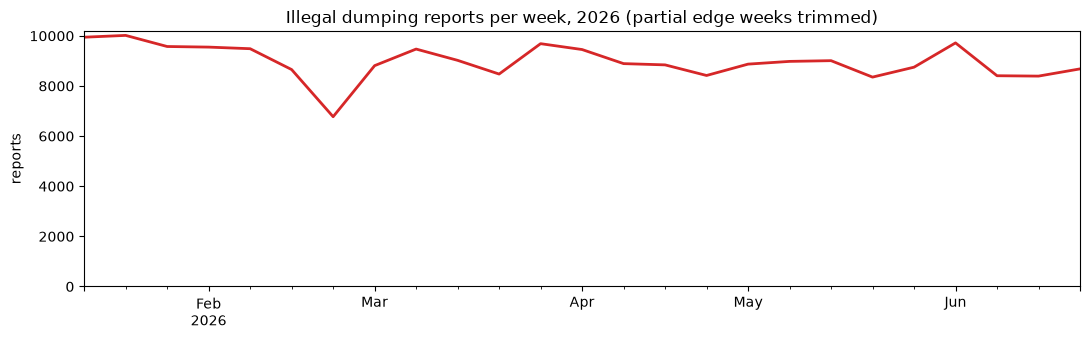

In [4]:
weekly = il.set_index("created").resample("W").size()

fig, ax = plt.subplots(figsize=(11, 3.5))
weekly.iloc[1:-1].plot(ax=ax, lw=2, color="tab:red")  # trim partial first/last weeks
ax.set_title("Illegal dumping reports per week, 2026 (partial edge weeks trimmed)")
ax.set_ylabel("reports")
ax.set_xlabel("")
ax.set_ylim(bottom=0)
plt.tight_layout()

print(f"Total Jan-Jun: {len(il):,}  ({len(il)/len(op):.1%} of all operational demand)")
print(f"Per day: {len(il)/181:,.0f}   Per hour: {len(il)/181/24:.0f}")
print(f"Weekly range (full weeks): {weekly.iloc[1:-1].min():,} - {weekly.iloc[1:-1].max():,}")

**What it shows:** ~231.5K reports in six months — **1,279 per day, or 53 every hour, around the clock**. That's 28.8% of everything operational the 311 system handles. Weekly volume is stable (8.4K–10K, February dip likely weather/short month); no trend break, no batch anomalies.

**Why it matters:** illegal dumping isn't an episodic problem; it's a *steady-state condition* the city services at industrial scale. The flatness also means H1-2026 results should generalize forward.

**Caveats:** reports, not piles (recurrence and duplicates inflate; invisible dumping deflates); six months can't show seasonality.

## 2. Intake — who reports, and when

Anonymous: 59%
Monthly: {1: 41400, 2: 33702, 3: 41462, 4: 38034, 5: 37819, 6: 39130}


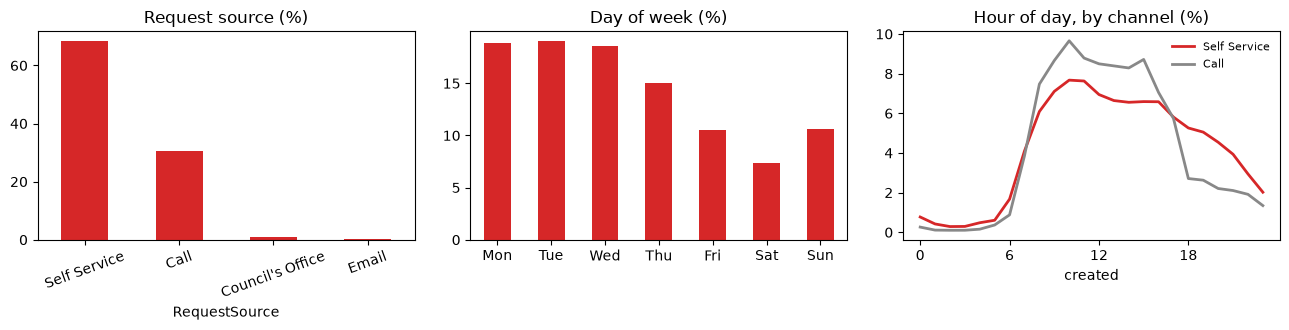

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

src = il["RequestSource"].value_counts(normalize=True).head(4) * 100
src.plot(kind="bar", ax=axes[0], color="tab:red", rot=20)
axes[0].set_title("Request source (%)")

dow = il["created"].dt.dayofweek.value_counts(normalize=True).sort_index() * 100
dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow.plot(kind="bar", ax=axes[1], color="tab:red", rot=0)
axes[1].set_title("Day of week (%)")

for ch, color in [("Self Service", "tab:red"), ("Call", "#888")]:
    hr = il.loc[il["RequestSource"] == ch, "created"].dt.hour.value_counts(normalize=True).sort_index() * 100
    hr.plot(ax=axes[2], lw=2, label=ch, color=color)
axes[2].set_title("Hour of day, by channel (%)")
axes[2].set_xticks(range(0, 24, 6))
axes[2].legend(frameon=False, fontsize=8)
plt.tight_layout()

print(f"Anonymous: {il['Anonymous'].mean():.0%}")
print(f"Monthly: {il['created'].dt.month.value_counts().sort_index().to_dict()}")

**What it shows and why it matters:**
- **Web-first (68%) and heavily anonymous (59%)** — consistent with third-party complaint behavior: people photograph a pile from the sidewalk and file quietly. The web skew also means dumping reports depend on digital access — a bias to remember in geographic comparisons.
- **Monday is the peak reporting day** (19%), tapering through the week to a Saturday trough (7%) — the classic "weekend accumulates, Monday reports" pattern, mirrored in the citywide rhythm but slightly sharper here.
- **Hourly:** self-service reports flow from ~6am through late evening (people report on morning walks and after work); the phone line's shape is just call-center hours.

**Caveats:** creation time ≠ dumping time — we observe the *reporting* clock, not the *dumping* clock (dumping presumably happens at night, invisible here); `recycLA`/crew channels are a rounding error in this category.

## 3. Operations — how the city handles it

18% of dumping cases are owned by LSD (the encampment division). We profile the two tracks separately before looking at outcomes.

In [6]:
il["segment"] = il["Owner"].map(
    lambda o: "LSD (encampment div.)" if o in ("LSD", "LASAN - LSD")
    else ("LASAN core" if o in ("LASAN", "Sanitation") else "other")
)

closed = il[(il["Status"] == "Closed") & (il["created"] < "2026-06-01")].copy()
closed["days"] = (pd.to_datetime(closed["ClosedDate"], format="mixed") - closed["created"]).dt.total_seconds() / 86400
closed["outcome"] = closed["ResolutionCode"].map(outcome_class)

seg = closed.groupby("segment").agg(
    n=("days", "size"),
    median_days=("days", "median"),
    p75_days=("days", lambda s: s.quantile(0.75)),
    p95_days=("days", lambda s: s.quantile(0.95)),
    pct_gone_on_arrival=("ResolutionCode", lambda s: (s == "QC-Item Not Out").mean() * 100),
).round(1)
seg

,n,median_days,p75_days,p95_days,pct_gone_on_arrival
segment,,,,,
LASAN core,156154,2.7,5.1,7.3,26.0
LSD (encampment div.),34218,1.0,2.9,8.5,26.0


**What it shows:** two service tracks with very different clocks. **LSD closes its dumping cases in a median of 1.0 day** — regular LASAN yards take 2.7 days. (LSD's CARE/CARE+ teams run scheduled regional sweeps with dedicated crews; encampment-adjacent debris gets picked up on the next pass.) Both tracks converge on the same 26% gone-on-arrival rate.

**Why it matters:** "how fast does LA clear dumping" has *two* answers, and blending them misstates both. Any later performance or equity analysis must hold segment constant.

**Caveat:** `days` measures case closure, not necessarily the moment the debris left the street.

Top resolution codes:
ResolutionCode
AR-Request Completed              69.7
QC-Item Not Out                   26.0
GI-General Information             1.9
1004-Closed                        1.4
ASG-Already Serviced               0.2
RBI-Reschedule for Bulky Items     0.2

same-day closures: 30%   within 7 days: 92%

response time by outcome:  AR (collected): median 1.96d   QC (gone on arrival): median 2.89d


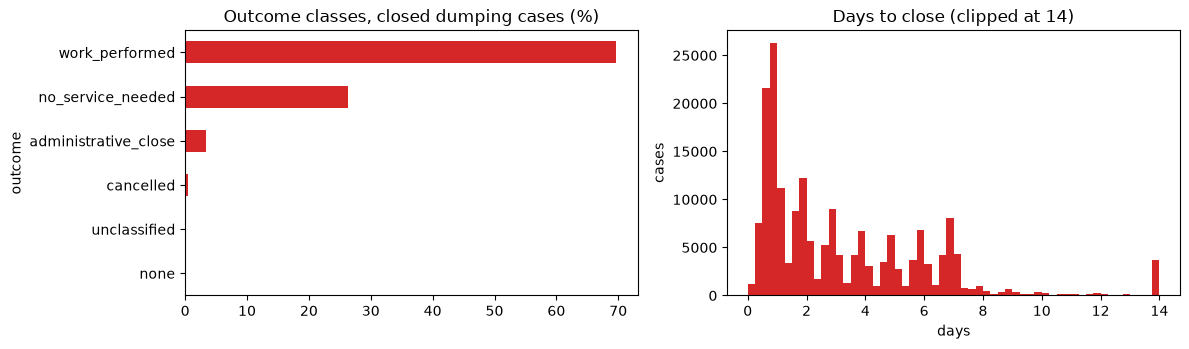

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

oc_pct = closed["outcome"].value_counts(normalize=True) * 100
oc_pct.iloc[::-1].plot(kind="barh", ax=axes[0], color="tab:red")
axes[0].set_title("Outcome classes, closed dumping cases (%)")

axes[1].hist(closed["days"].clip(upper=14), bins=56, color="tab:red")
axes[1].set_title("Days to close (clipped at 14)")
axes[1].set_xlabel("days")
axes[1].set_ylabel("cases")
plt.tight_layout()

print("Top resolution codes:")
print((closed["ResolutionCode"].value_counts(normalize=True).head(6) * 100).round(1).to_string())
print(f"\nsame-day closures: {(closed['days'] < 1).mean():.0%}   within 7 days: {(closed['days'] <= 7).mean():.0%}")
print(f"\nresponse time by outcome:  AR (collected): median "
      f"{closed.loc[closed['ResolutionCode'] == 'AR-Request Completed', 'days'].median():.2f}d   "
      f"QC (gone on arrival): median {closed.loc[closed['ResolutionCode'] == 'QC-Item Not Out', 'days'].median():.2f}d")

*A histogram (new chart type) shows the full shape of a distribution — how many cases closed in each band of days — which medians alone hide. We clip at 14 days so the long tail doesn't crush the visible mass.*

**What it shows:**
- Outcomes are essentially binary: **~71% collected (`work_performed`), ~26% gone on arrival (`no_service_needed`)**, and almost nothing else — no referral maze, no administrative limbo. Operationally this is a clean, industrialized workflow.
- The clock is fast and bounded: **30% same-day, 92% within a week** — visible as the mass piling up in days 0–5 with humps around the 1–4 day marks (collection-route cadence).
- **Gone-on-arrival cases took *longer* to close (median 2.9d) than collected ones (2.0d).** The direction is consistent with a race: the longer a pile sits on the work queue, the higher the chance scavengers/others clear it first. (Correlation, not proof — slower yards could also differ in other ways.)

**Why it matters:** the city is *not* failing to respond to dumping reports — response is quick and completion is high. Whatever makes dumping a persistent condition, it is not a broken ticket queue. The action is in **recurrence** (below) and in the quarter of dispatches that find nothing.

**Caveats:** censoring handled (≥30 days to close); closure ≠ verified-clean street; the QC/AR timing gap is confounded by geography and workload.

## 4. Geography, high level

We compare each Council District's *share of dumping* to its *share of all operational demand* — a ratio that self-corrects for population and general reporting propensity (1.0 = dumping proportional to overall 311 use).

APC share of dumping: {'South Los Angeles APC': 24.8, 'South Valley APC': 20.1, 'Central APC': 19.7, 'North Valley APC': 14.3, 'East Los Angeles APC': 9.6, 'West Los Angeles APC': 7.0, 'Harbor APC': 4.6}


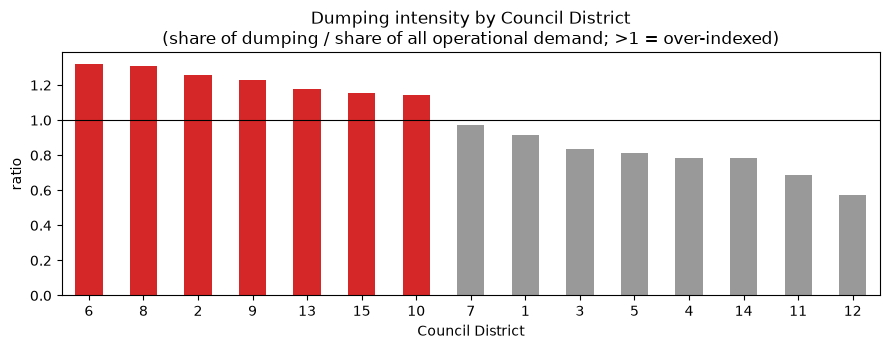

In [8]:
cd_il = il[il["CD"] > 0]["CD"].astype(int).value_counts(normalize=True) * 100
cd_op = op[op["CD"] > 0]["CD"].astype(int).value_counts(normalize=True) * 100
ratio = (cd_il / cd_op).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 3.6))
colors = ["tab:red" if v > 1 else "#999" for v in ratio]
ratio.plot(kind="bar", ax=ax, color=colors, rot=0)
ax.axhline(1, color="k", lw=0.8)
ax.set_title("Dumping intensity by Council District\n(share of dumping / share of all operational demand; >1 = over-indexed)")
ax.set_ylabel("ratio")
ax.set_xlabel("Council District")
plt.tight_layout()

apc = (il["APC"].value_counts(normalize=True) * 100).round(1)
print("APC share of dumping:", apc.to_dict())

Repeat locations (address-string level, 6 months):
  addresses reported 2+ times: 43,204
  share of all dumping cases at repeat addresses: 70%
  most-reported address: 4TH ST AND NEW HAMPSHIRE AVE (115 reports)


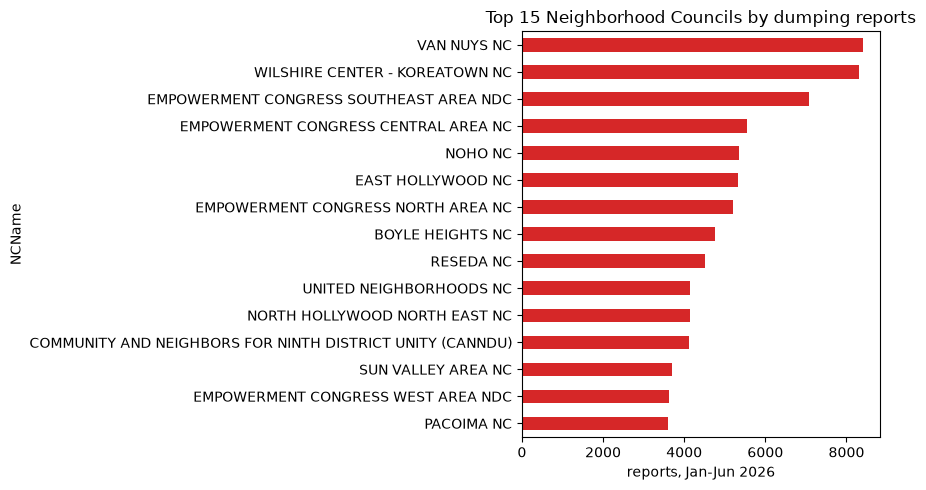

In [9]:
nc_il = il["NCName"].value_counts()
top15 = nc_il.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
top15.plot(kind="barh", ax=ax, color="tab:red")
ax.set_title("Top 15 Neighborhood Councils by dumping reports")
ax.set_xlabel("reports, Jan-Jun 2026")
plt.tight_layout()

addr = il["Address"].dropna().str.upper().str.strip()
vc = addr.value_counts()
print(f"Repeat locations (address-string level, 6 months):")
print(f"  addresses reported 2+ times: {(vc >= 2).sum():,}")
print(f"  share of all dumping cases at repeat addresses: {vc[vc >= 2].sum() / len(addr):.0%}")
print(f"  most-reported address: {vc.index[0]} ({vc.iloc[0]} reports)")

**What it shows:**
- **Council districts:** dumping over-indexes in CD6 (Van Nuys, 1.32), CD8 (South LA, 1.30), CD2 (East Valley, 1.25), CD9 (1.23), CD13 (1.18) — and under-indexes sharply in CD12 (0.58, NW Valley) and CD11 (0.68, Westside). Because the ratio controls for overall 311 usage, this is *dumping-specific* geography, not just "who reports more."
- **APC:** South LA alone carries 25% of dumping (vs ~20% of all demand).
- **Neighborhood Councils:** Van Nuys, Koreatown, and the South-LA Empowerment Congress areas lead.
- **The recurrence teaser:** even with crude address-string matching, **70% of all dumping reports occur at an address reported more than once in six months**; 43K addresses repeat; the top corner (4th St & New Hampshire Ave, Koreatown) was reported **115 times** — every ~37 hours.

**Why it matters:** demand is geographically *structured*, not random — a Valley-industrial + South-LA + Koreatown pattern — and overwhelmingly *recurrent at specific points*. The phenomenon to explain is not "where does dumping happen" but "why do the same places refill."

**Caveats (serious ones):** address strings under-merge (same corner spelled differently) *and* over-merge (large complexes); intersections geocode many piles to one label; repeat reports ≠ repeat dumping (one persistent pile can generate many reports — the duplicate-linking gap, standards §3); no per-capita/per-road-mile normalization yet; NC raw counts partly reflect NC size.

## 5. Questions we cannot answer yet

**This dataset cannot answer — flagged as stakeholder interview questions (LASAN operations, yard supervisors, LSD/CARE+ leads):**

1. **The marginal-pile policy:** when a crew responds to a work order and sees additional dumped items nearby that are *not* on the ticket, are they expected/allowed to collect them? Does the answer differ for LASAN yards vs LSD sweeps vs contractor crews?
2. **Proactive vs ticket-driven cleanup:** do any crews patrol known corridors without tickets (as LSD's CARE model suggests), and what share of collected tonnage is proactive? (The old CleanStat program scored streets proactively — does anything replace it in the new system?)
3. **On-scene discretion:** how do crews decide what to take when they arrive — size/hazard limits, private-vs-public property line, items requiring special handling (e-waste, white goods — the `REW`/`RWG` reschedule codes hint at this)?
4. What triggers routing a dumping case to **LSD vs a regular yard** — address proximity to a known encampment, keyword, dispatcher judgment?
5. Is there any **work-order linking** of repeat reports at the same location, or does each report dispatch independently (potentially several trucks to one pile)?

**Needs additional datasets:** per-capita/per-road-mile normalization (NC boundaries + census population, road centerlines); land-use context for hotspots (industrial vs residential); tonnage collected (LASAN publishes some solid-resources statistics) to convert case counts into material volume; camera/enforcement citation data for the deterrence side.

**Needs field investigation:** what a "gone on arrival" site looks like in reality; whether top repeat corners have visible enablers (vacant lots, alley mouths, unlit frontage, no nearby legal disposal); whether piles at repeat sites are single-source or accretive.

---

## What We Learned

1. Illegal dumping is **28.8% of all operational 311 demand** — ~1,279 reports/day, steady, no trend break.
2. Reporting is **web-first (68%) and anonymous-majority (59%)**, peaking Monday morning-to-evening; we observe the reporting clock, not the dumping clock.
3. Operationally it's a **clean two-outcome workflow**: ~71% collected, ~26% gone on arrival, closed fast (30% same-day, 92% within a week). The ticket queue is not the broken part.
4. There are **two service tracks**: LSD/CARE+ (18% of cases, median 1.0 day) vs regular yards (median 2.7 days).
5. Geography is structured (South LA + East Valley + Koreatown over-index even after controlling for overall 311 usage) and **profoundly recurrent: 70% of reports hit repeat addresses; the top corner refills every ~1.5 days**.

## What Surprised Us

- **How fast and complete the response is.** The popular narrative is "the city ignores dumping"; the data shows industrial-speed servicing. Persistence, not response failure, is the phenomenon.
- **The recurrence share (70%)** — even crude address matching shows the problem is dominated by refilling locations, not one-off events.
- **Gone-on-arrival piles had *slower* case clocks** — evidence of a race between city crews and informal clearance (scavengers, neighbors). A quarter of dispatches lose that race.
- LSD being the *faster* track — scheduled sweeps beat ticket dispatch on this category.

## New Questions Raised

1. What is a *location*, really? Address strings are too crude — recurrence needs point-coordinate clustering with distance thresholds. (Method question for the next notebook.)
2. Are repeat reports at a location *many piles* or *one long-lived pile reported repeatedly*? Inter-report timing vs closure timing at repeat sites may partially separate these.
3. Does the LASAN-vs-LSD speed gap hold within the same neighborhoods (or is it just geography)?
4. Do `QC-Item Not Out` rates rise with queue delay *within* a yard? (Cleaner test of the race hypothesis.)
5. What distinguishes the ~30 super-sites (50+ reports) from ordinary repeat corners? — directly feeds field-visit selection.

## Recommendations for the Next Notebook

**Notebook 05: Recurrence and hotspot structure of illegal dumping** — coordinate-based (not address-string) location clustering, recurrence-interval distributions, hotspot stability over the six months, and a ranked list of candidate field-visit sites. Driven by this notebook's central finding: recurrence at specific points *is* the illegal dumping problem. This also finally justifies introducing geospatial tooling (GeoPandas), which nothing before this needed.

Runner-up: the reporting-bias probe (O9/O10 — channel mix and crew-discovered cases by geography) — it would sharpen interpretation of hotspot maps, and could be folded into notebook 05's caveats instead of standing alone.